In [1]:
import numpy as np
import joblib 
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input


import warnings
warnings.filterwarnings("ignore")

In [2]:
model = load_model("../models/Effnet_model.keras")
label_encoder = joblib.load("../models/label_encoder.joblib")

print("Model loaded successfully")
print("Total classes:", len(label_encoder.classes_))

Model loaded successfully
Total classes: 75


In [3]:
def predict_butterfly(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)
    
    predicted_class = np.argmax(prediction)
    class_name = label_encoder.inverse_transform([predicted_class])[0]
    
    confidence = np.max(prediction)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_name} ({confidence:.2%})")
    plt.show()

    print("Prediction:", class_name)
    print("Confidence:", f"{confidence:.2%}")

    return class_name, confidence

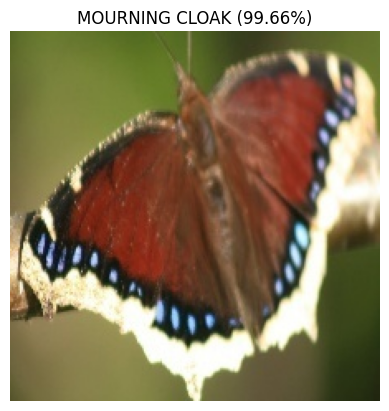

Prediction: MOURNING CLOAK
Confidence: 99.66%


In [9]:
img1 = "../test image/Image_73.jpg"
img2 = "../test image/Image_74.jpg"
predict_butterfly(img2)
plt.show()

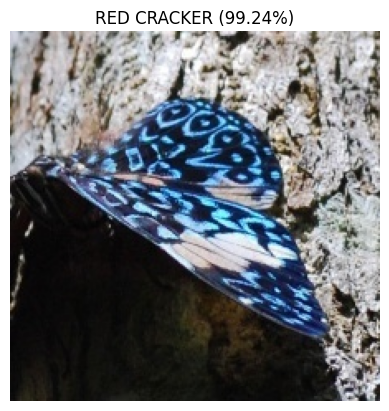

Prediction: RED CRACKER
Confidence: 99.24%


In [8]:
predict_butterfly(img1)
plt.show()

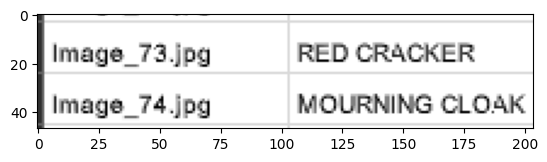

In [7]:
img3 = "../test image/image.png"
image_name = image.load_img(img3)
plt.imshow(image_name)
plt.show()